In [20]:
from pathlib import Path
import pickle as pkl
import sys

dirpath_root = Path().resolve().parents[1]
sys.path.append(str(dirpath_root))

from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from analysis.ou_tuning import xr_utils
import analysis.ou_tuning.netpyne_res_parse_utils as parse_utils
import analysis.ou_tuning.data_proc_utils as proc_utils

In [21]:
dirpath_res = Path('sim_output')

exp_name = 'sim_IT5A_kdr_mult_3_ramp_1.5_rx_75_wx_0.5_ouamp_-0.02_0.18'

# Load sim results
fpath_pkl = dirpath_res / exp_name / f'{exp_name}_data.pkl'
with open(fpath_pkl, 'rb') as fid:
    sim_res = pkl.load(fid)

In [22]:
pop_used = parse_utils.get_pop_names(sim_res)[0]
ncells = parse_utils.get_pop_size(sim_res, pop_used)

# Backround current
I_range = sim_res['simConfig']['OUamp']
I_vals = np.linspace(I_range[0], I_range[1], ncells)

In [23]:
time_ranges = [(2.5, 3.5), (6, 7)]   # before and after the impulse

# Extract voltages
V, tt = [], []
for t_limits in time_ranges:
    V_, tt_ = parse_utils.get_voltages(
        sim_res, np.array(t_limits) * 1000
    )
    V.append(V_[pop_used])
    tt.append(tt_)

# Convert V to xr.DataArray
V = np.stack(V, axis=2)  # shape (ncells, ntime, nranges)
V = xr.DataArray(
    V,
    dims=('cell', 'time', 't_range'),
    coords={
        'cell': np.arange(ncells),
        'I': ('cell', I_vals),
        'time': tt[0] - tt[0][0],
        't_range': [f'{a}-{b}s' for a, b in time_ranges]
    },
    name=f"V_{pop_used}"
)
#V

In [24]:
Vmin = V.min(dim='time')
Vmax = V.max(dim='time')
Vavg = V.mean(dim='time')

In [25]:
# Types of activity
act_types = {
    'rest': {
        'vmax_range': (-np.inf, -40),
        'colors': {'min': 'm', 'max': 'm', 'avg': 'r'},
        'show_avg': 1, 'show_minmax': 0
    },
    'block': {
        'vmax_range': (-40, 20),
        'colors': {'min': 'g', 'max': 'g', 'avg': 'b'},
        'show_avg': 1, 'show_minmax': 0
    },
    'spiking': {
        'vmax_range': (20, np.inf),
        'colors': {'min': 'k', 'max': 'k', 'avg': 'k'},
        'show_avg': 0, 'show_minmax': 1
    }
}

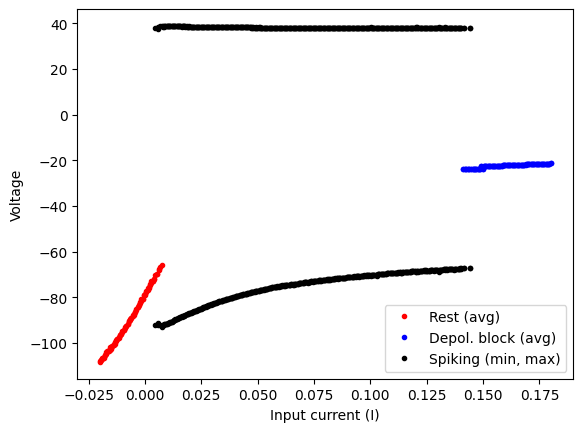

In [26]:
plt.figure()

for m, _ in enumerate(V['t_range']):
    for act_name, act_par in act_types.items():
        # Choose cells with a given activity type
        vmax = Vmax.isel(t_range=m)
        vv = act_par['vmax_range']
        mask = (vmax >= vv[0]) & (vmax < vv[1])

        ii = I_vals[mask]
        vmax = Vmax.isel(t_range=m).values[mask]
        vmin = Vmin.isel(t_range=m).values[mask]
        vavg = Vavg.isel(t_range=m).values[mask]

        if act_par['show_avg']:
            plt.plot(ii, vavg, '.', color=act_par['colors']['avg'])
        if act_par['show_minmax']:
            plt.plot(ii, vmax, '.', color=act_par['colors']['max'])
            plt.plot(ii, vmin, '.', color=act_par['colors']['min'])

plt.xlabel('Input current (I)')
plt.ylabel('Voltage')

# Legend
legend_elements = [
    Line2D([0], [0], marker='.', color='r', linestyle='None', label='Rest (avg)'),
    Line2D([0], [0], marker='.', color='b', linestyle='None', label='Depol. block (avg)'),
    Line2D([0], [0], marker='.', color='k', linestyle='None', label='Spiking (min, max)'),
]
plt.legend(handles=legend_elements)

# Save
dirpath_out = dirpath_res / exp_name
fname_out = f'vi_curve_{pop_used}.png'
plt.savefig(dirpath_out / fname_out, dpi=300)